# 📖 Notebook 01: トークン化と埋め込み
## — テキストを数値に変換する仕組み —

LLM はテキストをそのまま受け取れません。最初に行う前処理がこの章のテーマです。

### 全体の流れ

```
"hello"  →  [7, 4, 11, 11, 14]  →  行列 X_embed  →  + PE  →  X
  テキスト      トークンID列          埋め込みベクトル    位置情報   Transformer入力
```

### このノートで使うもの
- **numpy のみ**（外部 DL フレームワーク不要）
- **matplotlib**（計算結果の可視化）

---

### なぜこの変換が必要か

ニューラルネットワークは実数の行列演算で動きます。
テキスト（文字列）はそのままでは演算できないため、
**3 段階の変換**で実数行列に変換します：

| 段階 | 変換 | 例 |
|------|------|----|
| ① トークン化 | 文字列 → 整数列 | `"hello"` → `[7,4,11,11,14]` |
| ② 埋め込み | 整数 → 実数ベクトル | `7` → `[0.3, -1.2, 0.7, -0.5]` |
| ③ 位置符号化 | 位置情報を加算 | `+` sin/cos 行列 |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110, 'font.family': 'IPAGothic'})

# モデルの超パラメータ（小さい値で全数値が画面に収まるように）
vocab_size = 8
d_model    = 4   # 埋め込み次元（実際の GPT-4 は 12,288）
seq_len    = 4   # 系列長

print(f"vocab_size = {vocab_size}")
print(f"d_model    = {d_model}")
print(f"seq_len    = {seq_len}")

vocab_size = 8
d_model    = 4
seq_len    = 4


---
## ① トークン化

### 1-1. 文字レベルのトークン化

最もシンプルな「1文字 = 1トークン」方式です。
実際の GPT は **BPE（Byte Pair Encoding）** を使いますが、仕組みは同じです。

手順：
1. テキスト中の全ユニーク文字を列挙 → **語彙（vocabulary）**
2. 各文字に整数 ID を割り当て
3. テキストを ID の列に変換

In [2]:
text = "hello world"

# 語彙の構築
vocab    = sorted(set(text))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}

# テキスト → トークン ID 列
token_ids = [char2idx[c] for c in text]

print(f"テキスト    : '{text}'")
print(f"語彙        : {vocab}")
print(f"対応辞書    : {char2idx}")
print()
print("トークン化の詳細：")
for ch, idx in zip(text, token_ids):
    print(f"  '{ch}'  →  ID = {idx}")
print()
print(f"最終的な ID 列 : {token_ids}")

テキスト    : 'hello world'
語彙        : [' ', 'd', 'e', 'h', 'l', 'o', 'r', 'w']
対応辞書    : {' ': 0, 'd': 1, 'e': 2, 'h': 3, 'l': 4, 'o': 5, 'r': 6, 'w': 7}

トークン化の詳細：
  'h'  →  ID = 3
  'e'  →  ID = 2
  'l'  →  ID = 4
  'l'  →  ID = 4
  'o'  →  ID = 5
  ' '  →  ID = 0
  'w'  →  ID = 7
  'o'  →  ID = 5
  'r'  →  ID = 6
  'l'  →  ID = 4
  'd'  →  ID = 1

最終的な ID 列 : [3, 2, 4, 4, 5, 0, 7, 5, 6, 4, 1]


### 1-2. BPE（Byte Pair Encoding）の直感

実際の LLM は文字単位ではなく **サブワード単位** のトークンを使います。
BPE は「頻出するペアをひとつのトークンに合体させる」を繰り返すアルゴリズムです。

```
例: "aabc aab" に BPE を 2 回適用

初期:   [a, a, b, c, a, a, b]
Round1: 最頻ペア (a,a) → 新トークン 'aa'
        [aa, b, c, aa, b]
Round2: 最頻ペア (aa,b) → 新トークン 'aab'
        [aab, c, aab]
```

これにより「よく出る単語のかたまり」がひとつのトークンになります。
GPT-4 の語彙は約 **100,000** トークンです。

In [3]:
def get_pair_counts(tokens):
    counts = {}
    for pair in zip(tokens[:-1], tokens[1:]):
        counts[pair] = counts.get(pair, 0) + 1
    return counts

def merge_pair(tokens, pair, new_id):
    result, i = [], 0
    while i < len(tokens):
        if i < len(tokens)-1 and (tokens[i], tokens[i+1]) == pair:
            result.append(new_id); i += 2
        else:
            result.append(tokens[i]); i += 1
    return result

# a=0, b=1, c=2
tok_seq = [0, 0, 1, 2, 0, 0, 1]
name    = {0: 'a', 1: 'b', 2: 'c'}
next_id = 3

print(f"初期トークン列 : {[name[t] for t in tok_seq]}")
print()

for step in range(2):
    counts   = get_pair_counts(tok_seq)
    best     = max(counts, key=counts.get)
    new_name = name[best[0]] + name[best[1]]
    name[next_id] = new_name
    print(f"Round {step+1}: ペアのカウント = {dict([(name[a]+name[b], c) for (a,b),c in counts.items()])}")
    print(f"         最頻ペア = ('{name[best[0]]}', '{name[best[1]]}')  → 新トークン '{new_name}' (id={next_id})")
    tok_seq = merge_pair(tok_seq, best, next_id)
    print(f"         結果    = {[name[t] for t in tok_seq]}")
    print()
    next_id += 1

初期トークン列 : ['a', 'a', 'b', 'c', 'a', 'a', 'b']

Round 1: ペアのカウント = {'aa': 2, 'ab': 2, 'bc': 1, 'ca': 1}
         最頻ペア = ('a', 'a')  → 新トークン 'aa' (id=3)
         結果    = ['aa', 'b', 'c', 'aa', 'b']

Round 2: ペアのカウント = {'aab': 2, 'bc': 1, 'caa': 1}
         最頻ペア = ('aa', 'b')  → 新トークン 'aab' (id=4)
         結果    = ['aab', 'c', 'aab']



---
## ② 埋め込み行列（Embedding Table）

### なぜ埋め込みが必要か

整数 ID（例: 7）はそのままでは意味を持ちません。
`7 × 2 = 14` のような算術演算は「次のトークン予測」に意味をなさないからです。

**Embedding** は各トークンを $d_{\text{model}}$ 次元の実数ベクトルに対応させます：

$$E \in \mathbb{R}^{|V| \times d_{\text{model}}}$$

- 行数 = 語彙サイズ $|V|$
- 列数 = モデルの次元数 $d_{\text{model}}$
- 各行が 1 つのトークンを表すベクトル

**操作はただの「行の取り出し」**です：

$$\text{embed}(i) = E[i, :]$$

このベクトルは学習によって「意味的に近い単語は近いベクトル」になっていきます。

In [4]:
np.random.seed(42)
E = np.random.randn(vocab_size, d_model)

print(f"Embedding テーブル E : shape = {E.shape}")
print(f"（{vocab_size} 個のトークン × {d_model} 次元）")
print()
print("E（全体）:")
print(E)
print()

# トークン ID 3 の埋め込みベクトルを取り出す
token_id = 3
vec = E[token_id]
print(f"E[{token_id}] = {vec}  ← token_id={token_id} の埋め込みベクトル")

Embedding テーブル E : shape = (8, 4)
（8 個のトークン × 4 次元）

E（全体）:
[[ 0.4967 -0.1383  0.6477  1.523 ]
 [-0.2342 -0.2341  1.5792  0.7674]
 [-0.4695  0.5426 -0.4634 -0.4657]
 [ 0.242  -1.9133 -1.7249 -0.5623]
 [-1.0128  0.3142 -0.908  -1.4123]
 [ 1.4656 -0.2258  0.0675 -1.4247]
 [-0.5444  0.1109 -1.151   0.3757]
 [-0.6006 -0.2917 -0.6017  1.8523]]

E[3] = [ 0.242  -1.9133 -1.7249 -0.5623]  ← token_id=3 の埋め込みベクトル


In [5]:
# 複数トークンを一度にルックアップ
tokens = [2, 5, 1, 3]   # 今後ずっと使うトークン列
X_embed = E[tokens]     # shape: (seq_len, d_model)

print(f"tokens = {tokens}")
print(f"X_embed = E[tokens] : shape = {X_embed.shape}")
print()
print("X_embed（各行 = 各トークンのベクトル）:")
for i, (tid, row) in enumerate(zip(tokens, X_embed)):
    print(f"  位置 {i} | token_id={tid} | {row}")

print()
print("★ インデックス参照（E[tokens]）は行列積より高速 — 実装上の工夫")

tokens = [2, 5, 1, 3]
X_embed = E[tokens] : shape = (4, 4)

X_embed（各行 = 各トークンのベクトル）:
  位置 0 | token_id=2 | [-0.4695  0.5426 -0.4634 -0.4657]
  位置 1 | token_id=5 | [ 1.4656 -0.2258  0.0675 -1.4247]
  位置 2 | token_id=1 | [-0.2342 -0.2341  1.5792  0.7674]
  位置 3 | token_id=3 | [ 0.242  -1.9133 -1.7249 -0.5623]

★ インデックス参照（E[tokens]）は行列積より高速 — 実装上の工夫


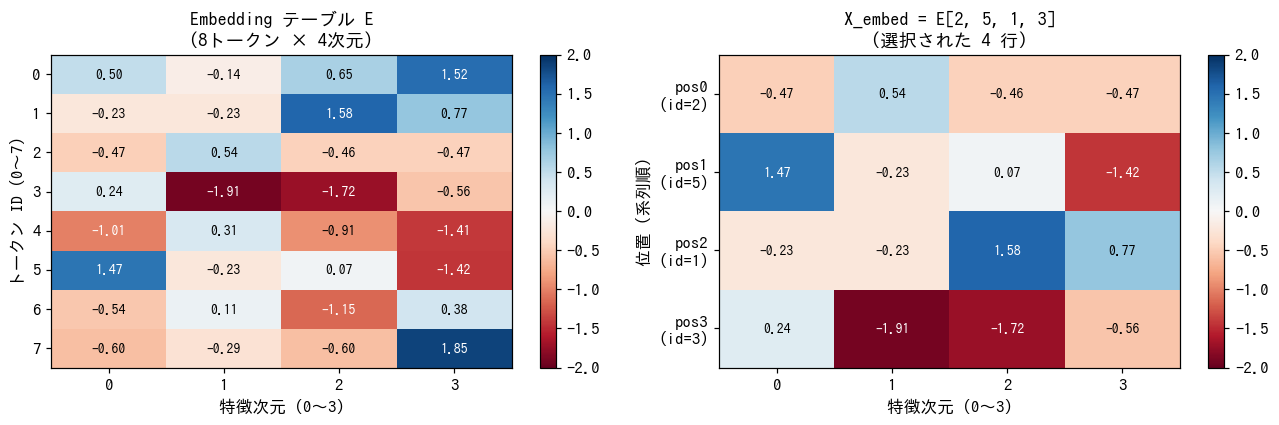

→ 赤=正の値、青=負の値。各行が 1 トークンのベクトル表現


In [6]:
# Embedding テーブルの可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：全テーブル
im0 = axes[0].imshow(E, cmap='RdBu', aspect='auto', vmin=-2, vmax=2)
axes[0].set_title('Embedding テーブル E\n(8トークン × 4次元)', fontsize=12)
axes[0].set_xlabel('特徴次元 (0〜3)', fontsize=11)
axes[0].set_ylabel('トークン ID (0〜7)', fontsize=11)
axes[0].set_xticks(range(d_model))
axes[0].set_yticks(range(vocab_size))
for i in range(vocab_size):
    for j in range(d_model):
        axes[0].text(j, i, f'{E[i,j]:.2f}', ha='center', va='center',
                     fontsize=9, color='white' if abs(E[i,j]) > 1 else 'black')
plt.colorbar(im0, ax=axes[0])

# 右：選択されたトークンの埋め込み
im1 = axes[1].imshow(X_embed, cmap='RdBu', aspect='auto', vmin=-2, vmax=2)
axes[1].set_title(f'X_embed = E{tokens}\n(選択された 4 行)', fontsize=12)
axes[1].set_xlabel('特徴次元 (0〜3)', fontsize=11)
axes[1].set_ylabel('位置 (系列順)', fontsize=11)
axes[1].set_xticks(range(d_model))
axes[1].set_yticks(range(seq_len))
axes[1].set_yticklabels([f'pos{i}\n(id={t})' for i, t in enumerate(tokens)])
for i in range(seq_len):
    for j in range(d_model):
        axes[1].text(j, i, f'{X_embed[i,j]:.2f}', ha='center', va='center',
                     fontsize=9, color='white' if abs(X_embed[i,j]) > 1 else 'black')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig('docs/nb01_embedding_table.png', dpi=120, bbox_inches='tight')
plt.show()
print("→ 赤=正の値、青=負の値。各行が 1 トークンのベクトル表現")

---
## ③ Positional Encoding（位置符号化）

### なぜ必要か

Embedding だけでは「A, B, C」と「C, B, A」が同じになってしまいます！
Self-Attention は各トークンを**並列に**処理するため、順序情報を別途与える必要があります。

### Vaswani et al. (2017) の正弦波方式

各位置 $pos$、各次元 $i$ について：

$$\text{PE}(pos,\; 2i)   = \sin\!\left(\frac{pos}{10000^{\,2i/d_{\text{model}}}}\right)$$

$$\text{PE}(pos,\; 2i+1) = \cos\!\left(\frac{pos}{10000^{\,2i/d_{\text{model}}}}\right)$$

**設計の意図：**
- 偶数次元 → sin、奇数次元 → cos
- 次元が上がるにつれて波の周期が長くなる（多スケール表現）
- 学習パラメータゼロ（固定式）
- 任意の長さの系列に適用可能

In [7]:
def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            angle = pos / (10000 ** (2 * i / d_model))
            PE[pos, i]   = np.sin(angle)
            if i + 1 < d_model:
                PE[pos, i+1] = np.cos(angle)
    return PE

PE = positional_encoding(seq_len, d_model)

print(f"Positional Encoding PE : shape = {PE.shape}")
print("（行 = トークン位置、列 = 次元）")
print()
print("PE の全値:")
print(PE)
print()

# 手計算での確認
print("━━━ 手計算確認 ━━━")
pos, i = 1, 0
denom  = 10000 ** (2 * i / d_model)   # 10000^0 = 1
angle  = pos / denom
print(f"PE[pos=1, dim=0]: sin(1 / 10000^(0/{d_model})) = sin({angle:.4f}) = {np.sin(angle):.4f}  ✓")
print(f"PE[pos=1, dim=1]: cos(1 / 10000^(0/{d_model})) = cos({angle:.4f}) = {np.cos(angle):.4f}  ✓")
print()
pos, i = 2, 1
denom  = 10000 ** (2 * i / d_model)   # 10000^0.5 = 100
angle  = pos / denom
print(f"PE[pos=2, dim=2]: sin(2 / 10000^(2/{d_model})) = sin({angle:.4f}) = {np.sin(angle):.4f}  ✓")
print(f"PE[pos=2, dim=3]: cos(2 / 10000^(2/{d_model})) = cos({angle:.4f}) = {np.cos(angle):.4f}  ✓")

Positional Encoding PE : shape = (4, 4)
（行 = トークン位置、列 = 次元）

PE の全値:
[[ 0.      1.      0.      1.    ]
 [ 0.8415  0.5403  0.0001  1.    ]
 [ 0.9093 -0.4161  0.0002  1.    ]
 [ 0.1411 -0.99    0.0003  1.    ]]

━━━ 手計算確認 ━━━
PE[pos=1, dim=0]: sin(1 / 10000^(0/4)) = sin(1.0000) = 0.8415  ✓
PE[pos=1, dim=1]: cos(1 / 10000^(0/4)) = cos(1.0000) = 0.5403  ✓

PE[pos=2, dim=2]: sin(2 / 10000^(2/4)) = sin(0.0200) = 0.0200  ✓
PE[pos=2, dim=3]: cos(2 / 10000^(2/4)) = cos(0.0200) = 0.9998  ✓


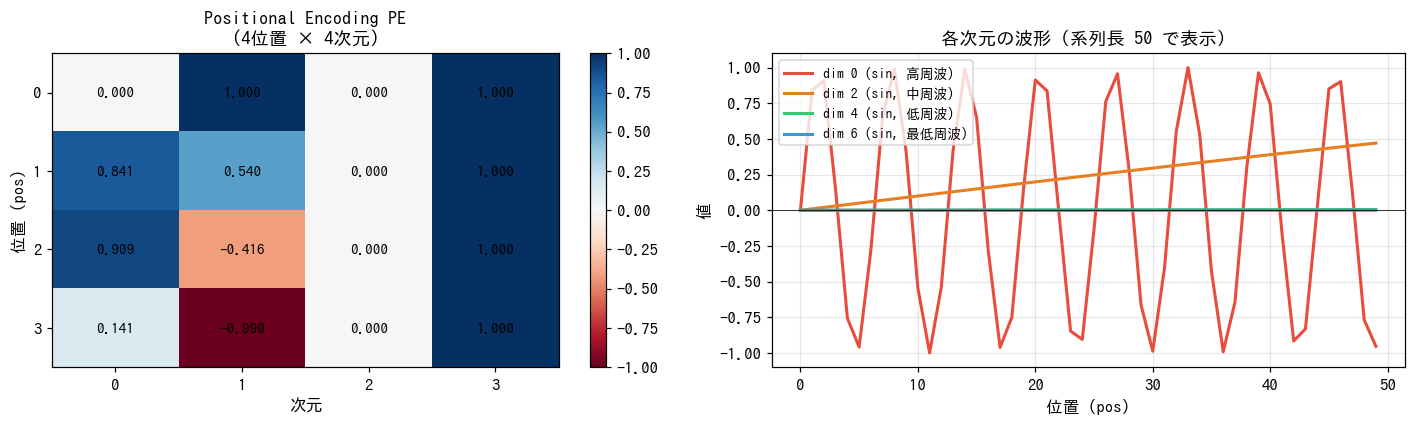

→ 次元が上がるほど波の周期が長くなる（多スケール表現）


In [8]:
# PE の可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：PE 行列のヒートマップ
im0 = axes[0].imshow(PE, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
axes[0].set_title('Positional Encoding PE\n(4位置 × 4次元)', fontsize=12)
axes[0].set_xlabel('次元', fontsize=11)
axes[0].set_ylabel('位置 (pos)', fontsize=11)
axes[0].set_xticks(range(d_model))
axes[0].set_yticks(range(seq_len))
for i in range(seq_len):
    for j in range(d_model):
        axes[0].text(j, i, f'{PE[i,j]:.3f}', ha='center', va='center', fontsize=10)
plt.colorbar(im0, ax=axes[0])

# 右：各次元の波形（長い系列で確認）
long_seq = 50
PE_long  = positional_encoding(long_seq, 8)   # d_model=8 で 4 種類の波を表示
colors   = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']
labels   = ['dim 0 (sin, 高周波)', 'dim 2 (sin, 中周波)', 'dim 4 (sin, 低周波)', 'dim 6 (sin, 最低周波)']
for idx, (dim, col, lab) in enumerate(zip([0, 2, 4, 6], colors, labels)):
    axes[1].plot(range(long_seq), PE_long[:, dim], color=col, label=lab, linewidth=2)
axes[1].set_title('各次元の波形（系列長 50 で表示）', fontsize=12)
axes[1].set_xlabel('位置 (pos)', fontsize=11)
axes[1].set_ylabel('値', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('docs/nb01_positional_encoding.png', dpi=120, bbox_inches='tight')
plt.show()
print("→ 次元が上がるほど波の周期が長くなる（多スケール表現）")

---
## ④ 最終入力行列 X の構築

$$X = X_{\text{embed}} + \text{PE} \in \mathbb{R}^{L \times d_{\text{model}}}$$

- $L$ = 系列長（seq_len）
- $d_{\text{model}}$ = モデルの次元数

この $X$ が Transformer の全層への入力になります。
同じ shape を保ちながら、各層で変換されていきます。

In [9]:
X = X_embed + PE   # 要素ごとの和 (4,4) + (4,4) = (4,4)

print(f"X_embed (埋め込みのみ):")
print(X_embed)
print()
print(f"PE (位置情報):")
print(PE)
print()
print(f"X = X_embed + PE  →  Transformer への入力")
print(f"shape = {X.shape}")
print(X)

# 手計算で 1 要素を確認
print()
print("━━━ 手計算確認（X[0, 0]）━━━")
print(f"X_embed[0,0] = {X_embed[0,0]:.4f}")
print(f"PE[0,0]      = {PE[0,0]:.4f}  （pos=0 の sin = sin(0) = 0.0）")
print(f"X[0,0]       = {X_embed[0,0]:.4f} + {PE[0,0]:.4f} = {X[0,0]:.4f}  ✓")

X_embed (埋め込みのみ):
[[-0.4695  0.5426 -0.4634 -0.4657]
 [ 1.4656 -0.2258  0.0675 -1.4247]
 [-0.2342 -0.2341  1.5792  0.7674]
 [ 0.242  -1.9133 -1.7249 -0.5623]]

PE (位置情報):
[[ 0.      1.      0.      1.    ]
 [ 0.8415  0.5403  0.0001  1.    ]
 [ 0.9093 -0.4161  0.0002  1.    ]
 [ 0.1411 -0.99    0.0003  1.    ]]

X = X_embed + PE  →  Transformer への入力
shape = (4, 4)
[[-0.4695  1.5426 -0.4634  0.5343]
 [ 2.3071  0.3145  0.0676 -0.4247]
 [ 0.6751 -0.6503  1.5794  1.7674]
 [ 0.3831 -2.9033 -1.7246  0.4377]]

━━━ 手計算確認（X[0, 0]）━━━
X_embed[0,0] = -0.4695
PE[0,0]      = 0.0000  （pos=0 の sin = sin(0) = 0.0）
X[0,0]       = -0.4695 + 0.0000 = -0.4695  ✓


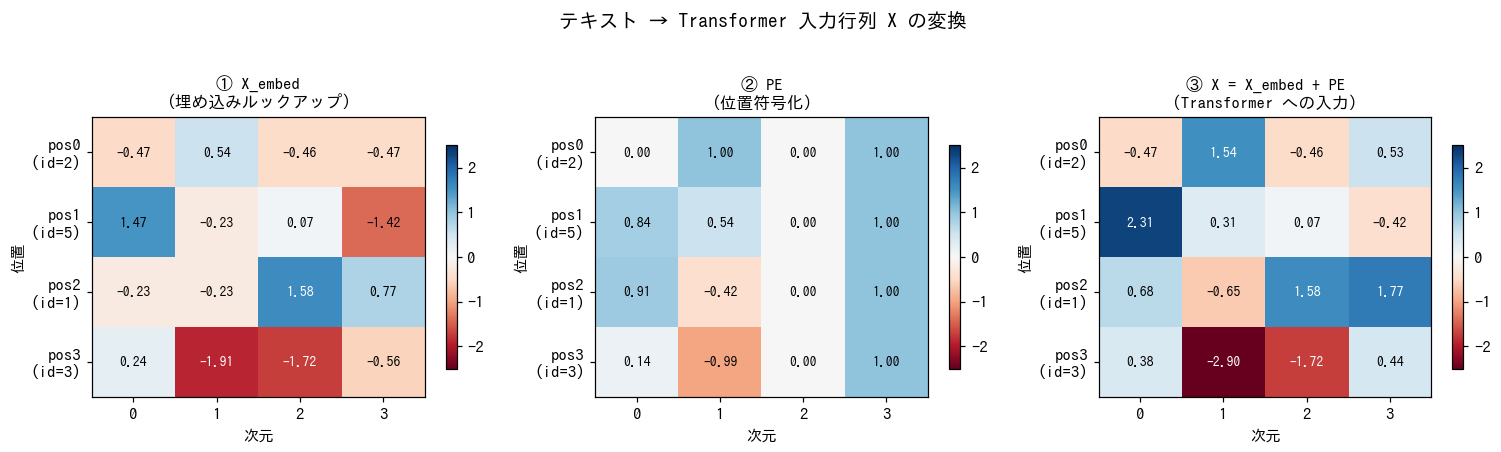

In [10]:
# X の構築を 3 段階で可視化
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
opts = dict(cmap='RdBu', aspect='auto', vmin=-2.5, vmax=2.5)
titles  = ['① X_embed\n（埋め込みルックアップ）', '② PE\n（位置符号化）', '③ X = X_embed + PE\n（Transformer への入力）']
mats    = [X_embed, PE, X]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.imshow(mat, **opts)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('次元', fontsize=10)
    ax.set_ylabel('位置', fontsize=10)
    ax.set_xticks(range(d_model))
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels([f'pos{i}\n(id={t})' for i, t in enumerate(tokens)])
    for i in range(seq_len):
        for j in range(d_model):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='white' if abs(mat[i,j]) > 1.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('テキスト → Transformer 入力行列 X の変換', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('docs/nb01_input_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

---
## まとめ

| ステップ | 式 / 操作 | 入力 shape | 出力 shape |
|---------|----------|-----------|----------|
| トークン化 | 文字 → 整数 ID | テキスト | `(seq_len,)` |
| 埋め込みルックアップ | $E[\text{ids}]$ | `(seq_len,)` | `(seq_len, d_model)` |
| 位置符号化 | $\sin/\cos$ | 位置インデックス | `(seq_len, d_model)` |
| **X の構築** | **$X_{\text{embed}} + \text{PE}$** | **`(seq_len, d_model)` × 2** | **`(seq_len, d_model)`** |

この **X**（shape: `(4, 4)`）が以降の全計算の出発点です。

→ **次: `02_self_attention.ipynb`** では、この X から Q/K/V を生成し、Attention を計算します。

```python
# 次のノートブックへの橋渡し
tokens = [2, 5, 1, 3]   # 今後もこのトークン列を使用
X      # shape (4, 4)   # この行列を次のノートブックに引き継ぐ
```